In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
import glob
import calendar

WEST AFRICA

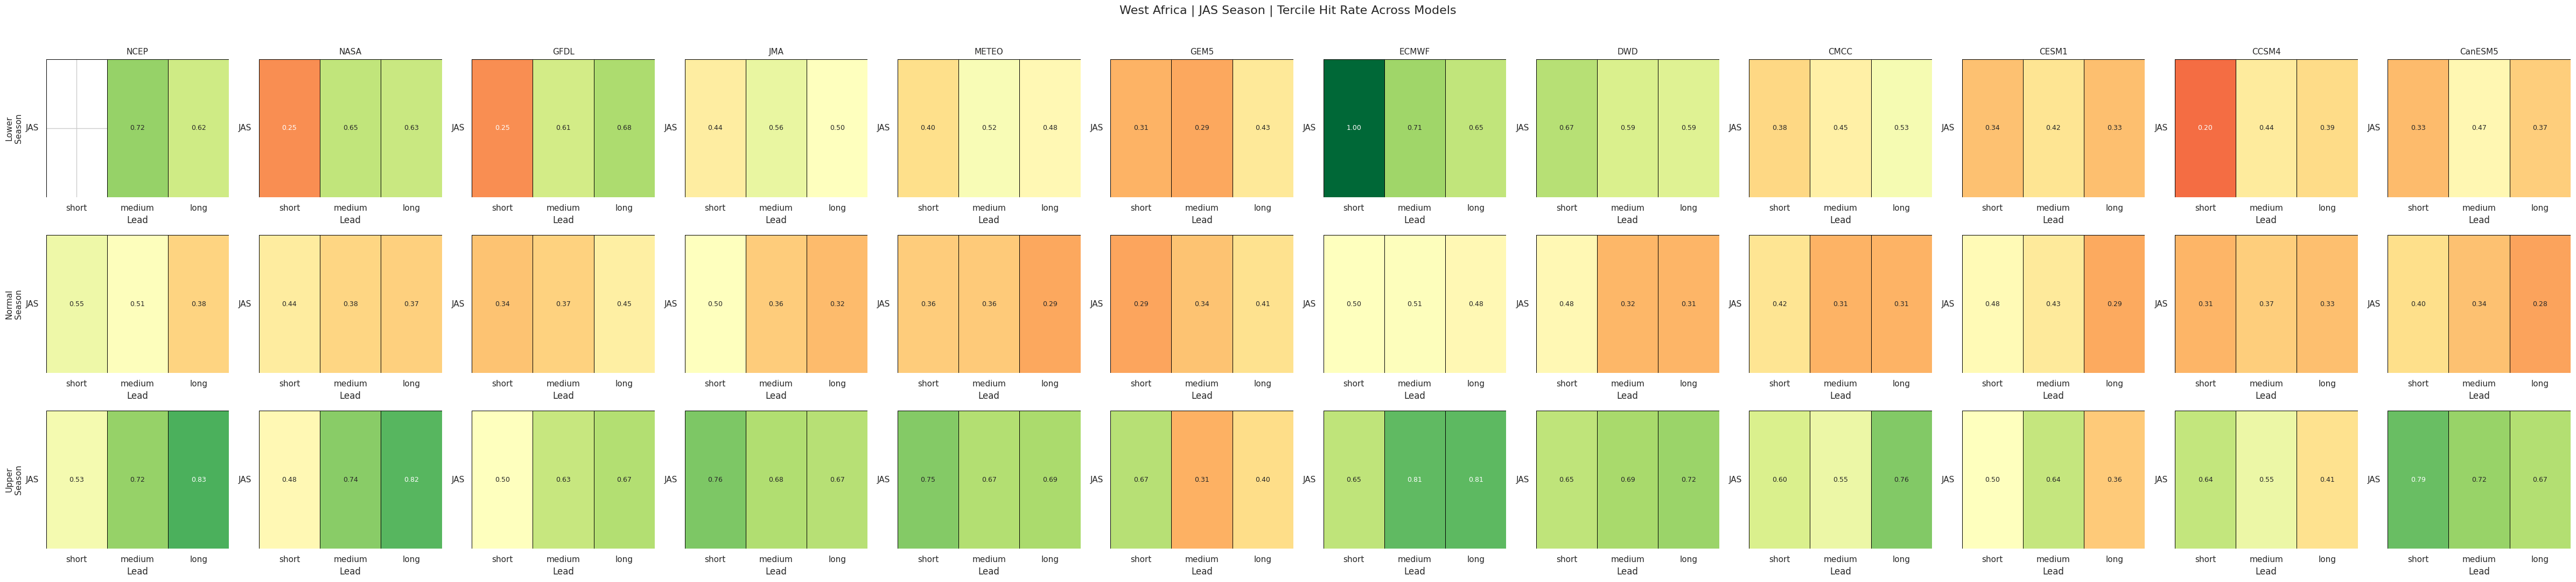

In [31]:
# Config
region = 'west_africa'
season = 'JAS'
season_months = [7, 8, 9]
models = ['NCEP', 'NASA', 'GFDL', 'JMA', 'METEO', 'GEM5', 'ECMWF', 'DWD', 'CMCC', 'CESM1', 'CCSM4', 'CanESM5']
terciles = ['lower', 'normal', 'upper']

# Lead category logic
def categorize_lead(lead):
    if 0 <= lead <= 1:
        return 'short'
    elif 2 <= lead <= 3:
        return 'medium'
    elif 4 <= lead <= 6:
        return 'long'
    return None

# Setup grid: 3 rows (terciles) × 12 columns (models)
fig, axes = plt.subplots(nrows=3, ncols=len(models), figsize=(4 * len(models), 11))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Loop over terciles and models
for row_idx, tercile_label in enumerate(terciles):
    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]

        file_path = f'/content/drive/MyDrive/capstone_data/csv/seasonal/{region}_{model}_merged_seasonal.csv'
        if not os.path.exists(file_path):
            ax.axis('off')
            ax.set_title(f"{model}\nFile Not Found", fontsize=10)
            continue

        # Load and preprocess
        df = pd.read_csv(file_path)
        if season not in df.columns:
            ax.axis('off')
            ax.set_title(f"{model}\nMissing Season", fontsize=10)
            continue
        # sptial mean grouping
        # Averages over space (latitude & longitude), since ensemble mean is already computed.
        # The result gives one forecast value and observed value per time-lead combination.

        df = df[df[season].notnull()].copy()
        df['time'] = pd.to_datetime(df['time'])
        df['month'] = df['time'].dt.month
        df['lead_time'] = df['lead_time'].astype(int)
        df = df[df['month'].isin(season_months)]

        df_grouped = df.groupby(['time', 'lead_time']).mean(numeric_only=True).reset_index()
        df_grouped['lead_category'] = df_grouped['lead_time'].apply(categorize_lead)
        df_grouped = df_grouped[df_grouped['lead_category'].notnull()]
        df_grouped['season_lead'] = season + "_" + df_grouped['lead_category']

        # Tercile thresholds
        ## Defines terciles using the 1/3 and 2/3 quantiles for both observed and predicted precipitation.
        ## Classifies each data point into lower, normal, or upper tercile.

        obs_lower = df_grouped['precip'].quantile(1/3)
        obs_upper = df_grouped['precip'].quantile(2/3)
        pred_lower = df_grouped['predicted_precip'].quantile(1/3)
        pred_upper = df_grouped['predicted_precip'].quantile(2/3)

        def classify_obs(val):
            if val <= obs_lower:
                return 'lower'
            elif val <= obs_upper:
                return 'normal'
            return 'upper'

        def classify_pred(val):
            if val <= pred_lower:
                return 'lower'
            elif val <= pred_upper:
                return 'normal'
            return 'upper'

        # hit rate total calculation with season grouped and lead time aggregation/grouping
        df_grouped['observed_tercile'] = df_grouped['precip'].apply(classify_obs)
        df_grouped['predicted_tercile'] = df_grouped['predicted_precip'].apply(classify_pred)
        df_grouped[f'{tercile_label}_hit'] = ((df_grouped['observed_tercile'] == tercile_label) &
                                              (df_grouped['predicted_tercile'] == tercile_label)).astype(int)

        preds = df_grouped[df_grouped['predicted_tercile'] == tercile_label]
        hit_rate = preds.groupby('season_lead')[f'{tercile_label}_hit'].mean().reset_index()
        hit_rate[['season', 'lead']] = hit_rate['season_lead'].str.split('_', expand=True)
        pivot = hit_rate.pivot(index='season', columns='lead', values=f'{tercile_label}_hit')

        for col in ['short', 'medium', 'long']:
            if col not in pivot.columns:
                pivot[col] = float('nan')
        pivot = pivot[['short', 'medium', 'long']]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            linewidths=0.5,
            linecolor='black',
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9},
            cbar=False
        )

        # Set titles and labels
        if row_idx == 0:
            ax.set_title(model, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{tercile_label.capitalize()}\nSeason", fontsize=11)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Lead")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Super title
plt.suptitle(f"{region.replace('_', ' ').title()} | JAS Season | Tercile Hit Rate Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


ECMWF is highly accurate at predicting lower-than-normal precipitation (i.e., drought or dry periods) especially at short lead times, with a perfect hit rate (1.00). Even at medium and long leads, performance remains strong.

Forecasting normal (average) rainfall is more difficult. The hit rates are modest across all lead times (all around ~0.35), meaning ECMWF has less skill in identifying when rainfall is expected to be near average.

ECMWF performs well at predicting above-normal rainfall, maintaining a stable hit rate (~0.6) across all lead times. This shows good skill in anticipating wetter-than-normal conditions.



EASTERN EAST AFRICA

<ipython-input-33-ea18fbfde899>:42: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-33-ea18fbfde899>:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']
<ipython-input-33-ea18fbfde899>:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped['observed_tercile'] = df_grouped['precip'].apply(
<ipython-input-33-ea18fbfde899>:64: 

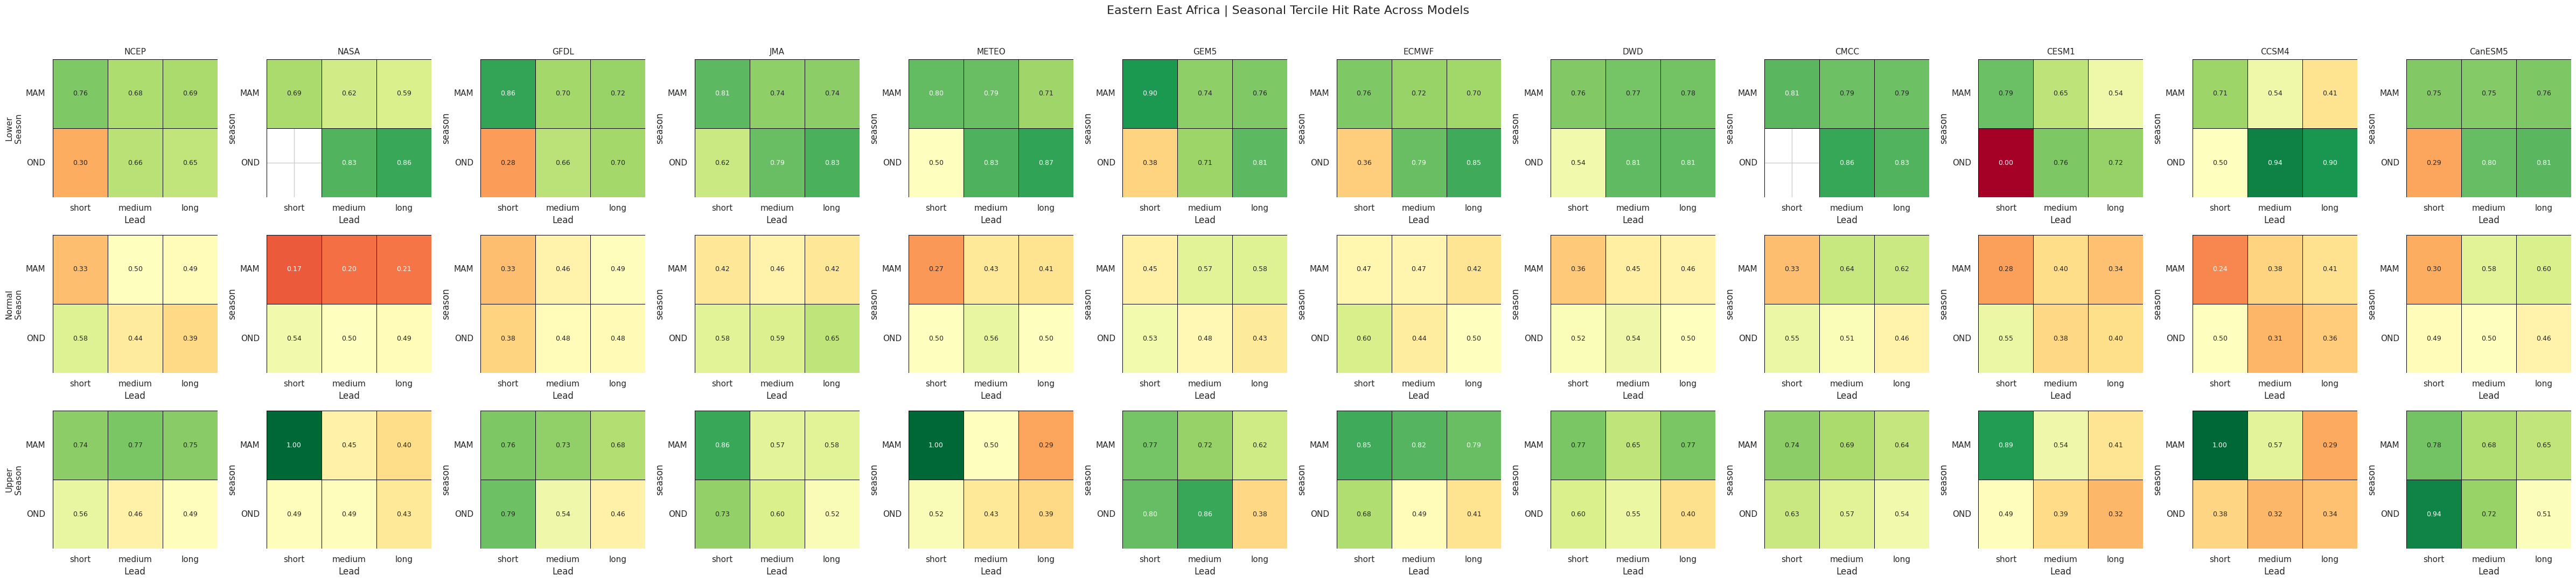

In [33]:
# Configuration for Eastern East Africa
models = ['NCEP', 'NASA', 'GFDL', 'JMA', 'METEO', 'GEM5', 'ECMWF', 'DWD', 'CMCC', 'CESM1', 'CCSM4', 'CanESM5']
region = 'eastern_east_africa'
seasons = {'MAM': [3, 4, 5], 'OND': [10, 11, 12]}
terciles = ['lower', 'normal', 'upper']
all_months = [3, 4, 5, 10, 11, 12]

def categorize_lead(lead):
    if 0 <= lead <= 1:
        return 'short'
    elif 2 <= lead <= 3:
        return 'medium'
    elif 4 <= lead <= 6:
        return 'long'
    return None

def assign_season(month):
    for sname, months in seasons.items():
        if month in months:
            return sname
    return None

sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=len(models), figsize=(4 * len(models), 11))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for row_idx, tercile_label in enumerate(terciles):
    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]
        file_path = f'/content/drive/MyDrive/capstone_data/csv/seasonal/{region}_{model}_merged_seasonal.csv'

        if not os.path.exists(file_path):
            ax.axis('off')
            ax.set_title(f"{model}\nFile Not Found", fontsize=10)
            continue

        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df['month'] = df['time'].dt.month
        df['lead_time'] = df['lead_time'].astype(int)

        df = df[df['MAM'].notnull() | df['OND'].notnull()]
        df = df[df['month'].isin(all_months)]

        # spatial mean work
        df_grouped = df.groupby(['time', 'lead_time']).mean(numeric_only=True).reset_index()
        df_grouped['month'] = df_grouped['time'].dt.month
        df_grouped['lead_category'] = df_grouped['lead_time'].apply(categorize_lead)
        df_grouped['season'] = df_grouped['month'].apply(assign_season)
        df_grouped = df_grouped[df_grouped['lead_category'].notnull() & df_grouped['season'].notnull()]
        df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']

        # Tercile compute threshold
        obs_lower = df_grouped['precip'].quantile(1/3)
        obs_upper = df_grouped['precip'].quantile(2/3)
        pred_lower = df_grouped['predicted_precip'].quantile(1/3)
        pred_upper = df_grouped['predicted_precip'].quantile(2/3)

        df_grouped['observed_tercile'] = df_grouped['precip'].apply(
            lambda val: 'lower' if val <= obs_lower else 'normal' if val <= obs_upper else 'upper')
        df_grouped['predicted_tercile'] = df_grouped['predicted_precip'].apply(
            lambda val: 'lower' if val <= pred_lower else 'normal' if val <= pred_upper else 'upper')

        df_grouped[f'{tercile_label}_hit'] = (
            (df_grouped['observed_tercile'] == tercile_label) &
            (df_grouped['predicted_tercile'] == tercile_label)
        ).astype(int)

        preds = df_grouped[df_grouped['predicted_tercile'] == tercile_label]
        hit_rate = preds.groupby('season_lead')[f'{tercile_label}_hit'].mean().reset_index()

        if hit_rate.empty:
            ax.axis('off')
            ax.set_title(f"{model}\nNo Data", fontsize=10)
            continue

        hit_rate[['season', 'lead']] = hit_rate['season_lead'].str.split('_', expand=True)
        pivot = hit_rate.pivot(index='season', columns='lead', values=f'{tercile_label}_hit')

        for col in ['short', 'medium', 'long']:
            if col not in pivot.columns:
                pivot[col] = float('nan')
        pivot = pivot[['short', 'medium', 'long']]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            linewidths=0.5,
            linecolor='black',
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9},
            cbar=False
        )

        if row_idx == 0:
            ax.set_title(model, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{tercile_label.capitalize()}\nSeason", fontsize=11)

        ax.set_xlabel("Lead")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle(f"{region.replace('_', ' ').title()} | Seasonal Tercile Hit Rate Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


SOUTH SUDAN

<ipython-input-34-e87def45589f>:46: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-34-e87def45589f>:46: DtypeWarning: Columns (7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-34-e87def45589f>:46: DtypeWarning: Columns (7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-34-e87def45589f>:46: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-34-e87def45589f>:46: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-34-e87def45589f>:46: DtypeWarning: Columns (7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv

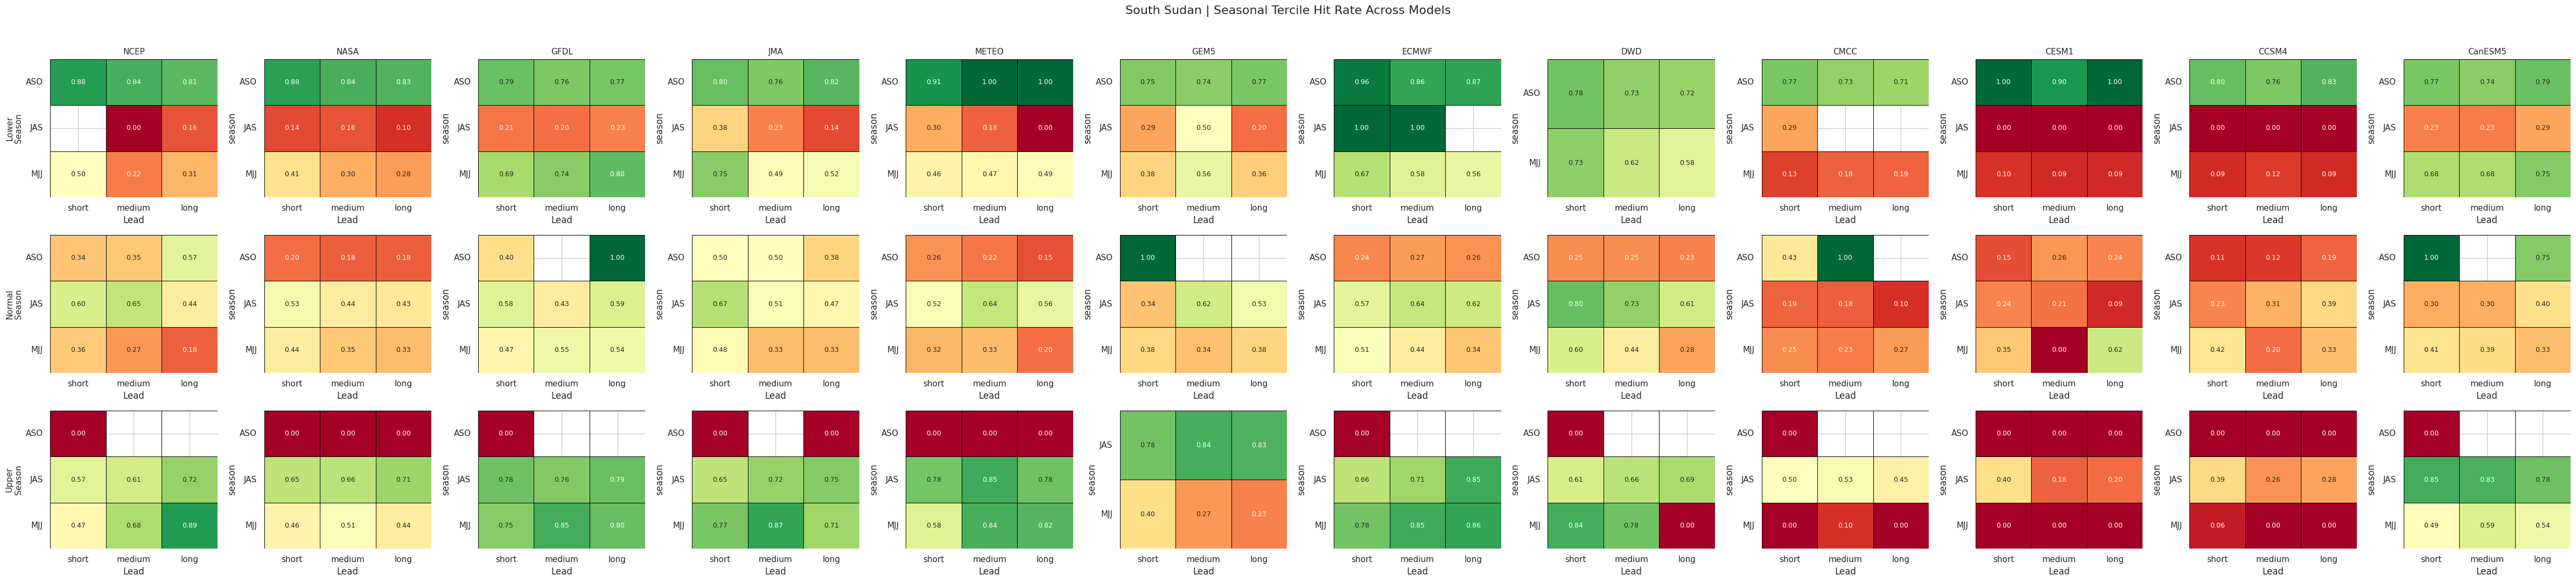

In [34]:
# Configuration for South Sudan
models = ['NCEP', 'NASA', 'GFDL', 'JMA', 'METEO', 'GEM5', 'ECMWF', 'DWD', 'CMCC', 'CESM1', 'CCSM4', 'CanESM5']
region = 'south_sudan'
season_months = {
    'MJJ': [5, 6, 7],
    'JAS': [7, 8, 9],
    'ASO': [8, 9, 10]
}
terciles = ['lower', 'normal', 'upper']
all_months = sorted(set(m for months in season_months.values() for m in months))

def categorize_lead(lead):
    if 0 <= lead <= 1:
        return 'short'
    elif 2 <= lead <= 3:
        return 'medium'
    elif 4 <= lead <= 6:
        return 'long'
    return None

def assign_season(month):
    for sname, months in season_months.items():
        if month in months:
            return sname
    return None

sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=len(models), figsize=(4 * len(models), 11))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for row_idx, tercile_label in enumerate(terciles):
    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]
        file_path = f'/content/drive/MyDrive/capstone_data/csv/seasonal/{region}_{model}_merged_seasonal.csv'

        if not os.path.exists(file_path):
            ax.axis('off')
            ax.set_title(f"{model}\nFile Not Found", fontsize=10)
            continue

        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df['month'] = df['time'].dt.month
        df['lead_time'] = df['lead_time'].astype(int)
        df = df[df['month'].isin(all_months)]

        df_grouped = df.groupby(['time', 'lead_time']).mean(numeric_only=True).reset_index()
        df_grouped['month'] = df_grouped['time'].dt.month
        df_grouped['lead_category'] = df_grouped['lead_time'].apply(categorize_lead)
        df_grouped['season'] = df_grouped['month'].apply(assign_season)
        df_grouped = df_grouped[df_grouped['lead_category'].notnull() & df_grouped['season'].notnull()]
        df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']

        obs_lower = df_grouped['precip'].quantile(1/3)
        obs_upper = df_grouped['precip'].quantile(2/3)
        pred_lower = df_grouped['predicted_precip'].quantile(1/3)
        pred_upper = df_grouped['predicted_precip'].quantile(2/3)

        df_grouped['observed_tercile'] = df_grouped['precip'].apply(
            lambda val: 'lower' if val <= obs_lower else 'normal' if val <= obs_upper else 'upper')
        df_grouped['predicted_tercile'] = df_grouped['predicted_precip'].apply(
            lambda val: 'lower' if val <= pred_lower else 'normal' if val <= pred_upper else 'upper')

        df_grouped[f'{tercile_label}_hit'] = (
            (df_grouped['observed_tercile'] == tercile_label) &
            (df_grouped['predicted_tercile'] == tercile_label)
        ).astype(int)

        preds = df_grouped[df_grouped['predicted_tercile'] == tercile_label]
        hit_rate = preds.groupby('season_lead')[f'{tercile_label}_hit'].mean().reset_index()

        if hit_rate.empty:
            ax.axis('off')
            ax.set_title(f"{model}\nNo Data", fontsize=10)
            continue

        hit_rate[['season', 'lead']] = hit_rate['season_lead'].str.split('_', expand=True)
        pivot = hit_rate.pivot(index='season', columns='lead', values=f'{tercile_label}_hit')

        for col in ['short', 'medium', 'long']:
            if col not in pivot.columns:
                pivot[col] = float('nan')
        pivot = pivot[['short', 'medium', 'long']]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            linewidths=0.5,
            linecolor='black',
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9},
            cbar=False
        )

        if row_idx == 0:
            ax.set_title(model, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{tercile_label.capitalize()}\nSeason", fontsize=11)

        ax.set_xlabel("Lead")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle(f"{region.replace('_', ' ').title()} | Seasonal Tercile Hit Rate Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


LAKE VICTORIA BASIN

<ipython-input-35-3edec8ff2218>:46: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-35-3edec8ff2218>:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']
<ipython-input-35-3edec8ff2218>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped['observed_tercile'] = df_grouped['precip'].apply(
<ipython-input-35-3edec8ff2218>:66: 

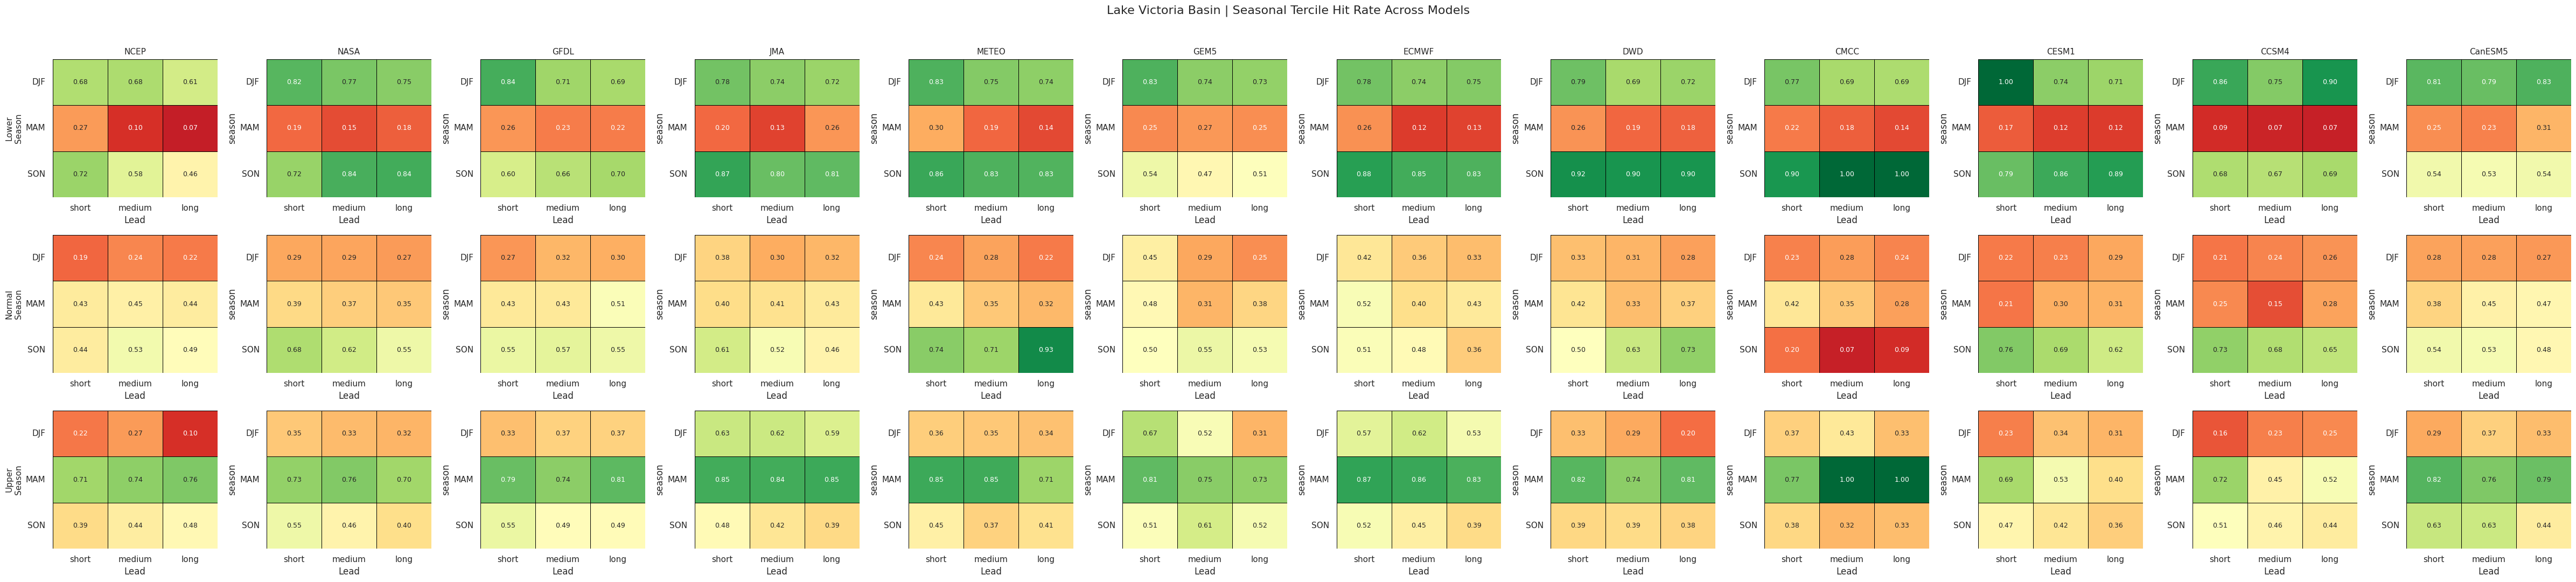

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration for Lake Victoria Basin
models = ['NCEP', 'NASA', 'GFDL', 'JMA', 'METEO', 'GEM5', 'ECMWF', 'DWD', 'CMCC', 'CESM1', 'CCSM4', 'CanESM5']
region = 'lake_victoria_basin'
season_months = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'SON': [9, 10, 11]
}
terciles = ['lower', 'normal', 'upper']
all_months = sorted(set(m for months in season_months.values() for m in months))

def categorize_lead(lead):
    if 0 <= lead <= 1:
        return 'short'
    elif 2 <= lead <= 3:
        return 'medium'
    elif 4 <= lead <= 6:
        return 'long'
    return None

def assign_season(month):
    for sname, months in season_months.items():
        if month in months:
            return sname
    return None

sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=len(models), figsize=(4 * len(models), 11))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for row_idx, tercile_label in enumerate(terciles):
    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]
        file_path = f'/content/drive/MyDrive/capstone_data/csv/seasonal/{region}_{model}_merged_seasonal.csv'

        if not os.path.exists(file_path):
            ax.axis('off')
            ax.set_title(f"{model}\nFile Not Found", fontsize=10)
            continue

        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df['month'] = df['time'].dt.month
        df['lead_time'] = df['lead_time'].astype(int)
        df = df[df['month'].isin(all_months)]

        df_grouped = df.groupby(['time', 'lead_time']).mean(numeric_only=True).reset_index()
        df_grouped['month'] = df_grouped['time'].dt.month
        df_grouped['lead_category'] = df_grouped['lead_time'].apply(categorize_lead)
        df_grouped['season'] = df_grouped['month'].apply(assign_season)
        df_grouped = df_grouped[df_grouped['lead_category'].notnull() & df_grouped['season'].notnull()]
        df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']

        obs_lower = df_grouped['precip'].quantile(1/3)
        obs_upper = df_grouped['precip'].quantile(2/3)
        pred_lower = df_grouped['predicted_precip'].quantile(1/3)
        pred_upper = df_grouped['predicted_precip'].quantile(2/3)

        df_grouped['observed_tercile'] = df_grouped['precip'].apply(
            lambda val: 'lower' if val <= obs_lower else 'normal' if val <= obs_upper else 'upper')
        df_grouped['predicted_tercile'] = df_grouped['predicted_precip'].apply(
            lambda val: 'lower' if val <= pred_lower else 'normal' if val <= pred_upper else 'upper')

        df_grouped[f'{tercile_label}_hit'] = (
            (df_grouped['observed_tercile'] == tercile_label) &
            (df_grouped['predicted_tercile'] == tercile_label)
        ).astype(int)

        preds = df_grouped[df_grouped['predicted_tercile'] == tercile_label]
        hit_rate = preds.groupby('season_lead')[f'{tercile_label}_hit'].mean().reset_index()

        if hit_rate.empty:
            ax.axis('off')
            ax.set_title(f"{model}\nNo Data", fontsize=10)
            continue

        hit_rate[['season', 'lead']] = hit_rate['season_lead'].str.split('_', expand=True)
        pivot = hit_rate.pivot(index='season', columns='lead', values=f'{tercile_label}_hit')

        for col in ['short', 'medium', 'long']:
            if col not in pivot.columns:
                pivot[col] = float('nan')
        pivot = pivot[['short', 'medium', 'long']]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            linewidths=0.5,
            linecolor='black',
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9},
            cbar=False
        )

        if row_idx == 0:
            ax.set_title(model, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{tercile_label.capitalize()}\nSeason", fontsize=11)

        ax.set_xlabel("Lead")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle(f"{region.replace('_', ' ').title()} | Seasonal Tercile Hit Rate Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



EASTERN UKRAINE




<ipython-input-36-c70066234cb9>:42: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-36-c70066234cb9>:42: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-36-c70066234cb9>:42: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-36-c70066234cb9>:42: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-36-c70066234cb9>:42: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-36-c70066234cb9>:42: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fil

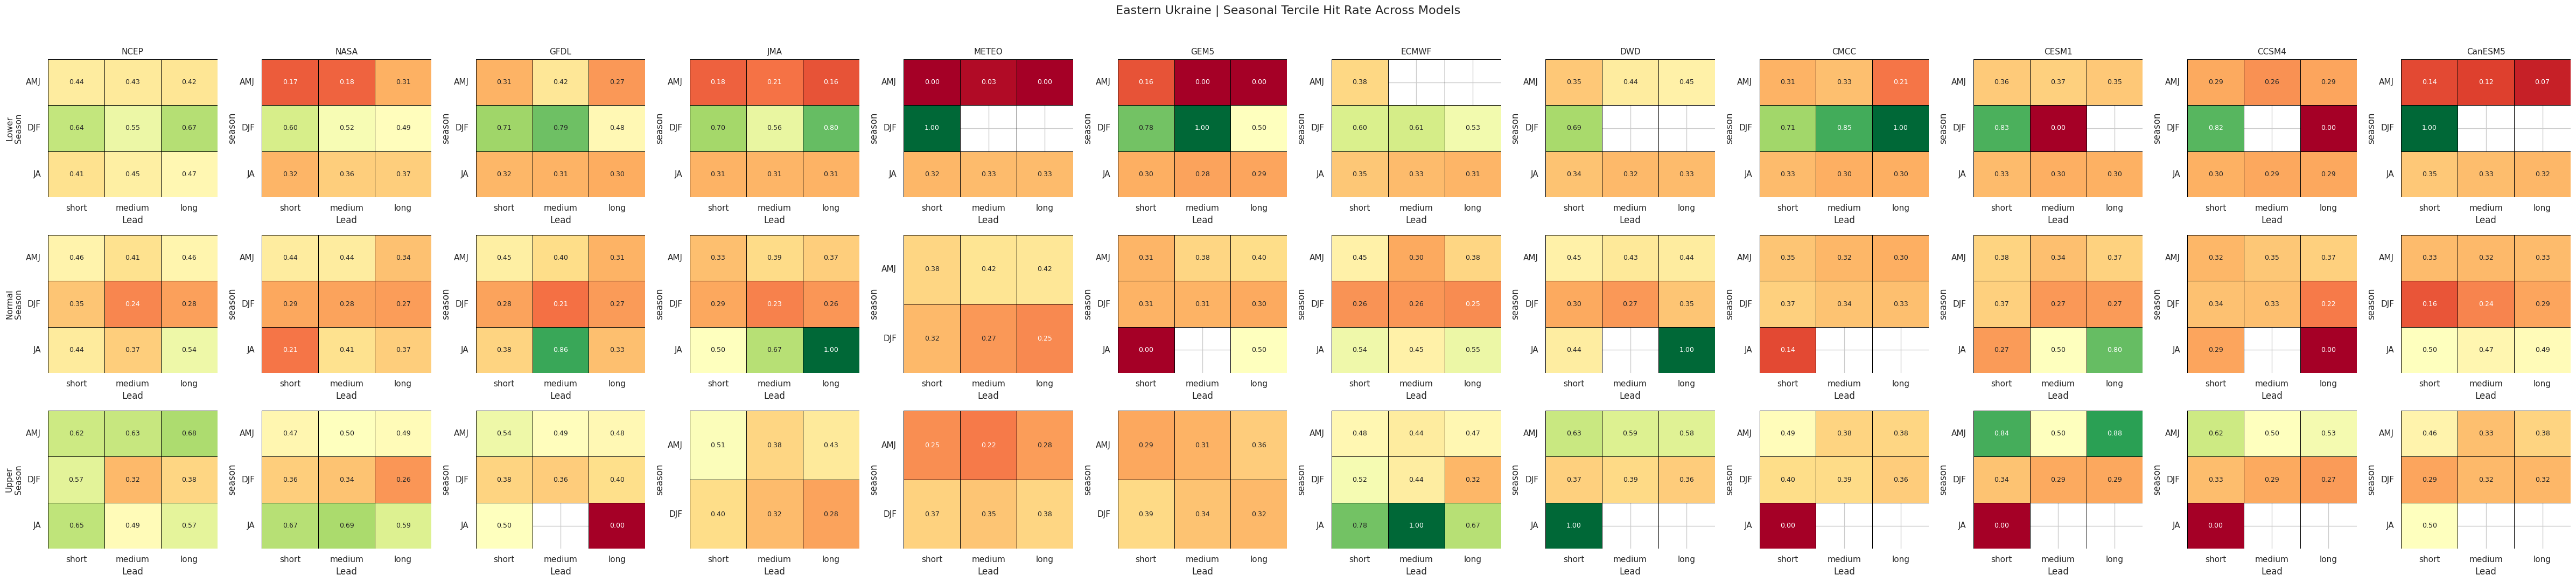

In [36]:
# Configuration for Eastern Ukraine
region = 'eastern_ukraine'
models = ['NCEP', 'NASA', 'GFDL', 'JMA', 'METEO', 'GEM5', 'ECMWF', 'DWD', 'CMCC', 'CESM1', 'CCSM4', 'CanESM5']
season_months = {
    'DJF': [12, 1, 2],
    'AMJ': [4, 5, 6],
    'JA': [7, 8]
}
terciles = ['lower', 'normal', 'upper']
all_months = sorted(set(m for months in season_months.values() for m in months))

def categorize_lead(lead):
    if 0 <= lead <= 1:
        return 'short'
    elif 2 <= lead <= 3:
        return 'medium'
    elif 4 <= lead <= 6:
        return 'long'
    return None

def assign_season(month):
    for sname, months in season_months.items():
        if month in months:
            return sname
    return None

# Create grid of subplots
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=len(models), figsize=(4 * len(models), 11))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for row_idx, tercile_label in enumerate(terciles):
    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]
        file_path = f'/content/drive/MyDrive/capstone_data/csv/seasonal/{region}_{model}_merged_seasonal.csv'

        if not os.path.exists(file_path):
            ax.axis('off')
            ax.set_title(f"{model}\nFile Not Found", fontsize=10)
            continue

        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df['month'] = df['time'].dt.month
        df['lead_time'] = df['lead_time'].astype(int)
        df = df[df['month'].isin(all_months)]

        df_grouped = df.groupby(['time', 'lead_time']).mean(numeric_only=True).reset_index()
        df_grouped['month'] = df_grouped['time'].dt.month
        df_grouped['lead_category'] = df_grouped['lead_time'].apply(categorize_lead)
        df_grouped['season'] = df_grouped['month'].apply(assign_season)
        df_grouped = df_grouped[df_grouped['lead_category'].notnull() & df_grouped['season'].notnull()]
        df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']

        obs_lower = df_grouped['precip'].quantile(1/3)
        obs_upper = df_grouped['precip'].quantile(2/3)
        pred_lower = df_grouped['predicted_precip'].quantile(1/3)
        pred_upper = df_grouped['predicted_precip'].quantile(2/3)

        df_grouped['observed_tercile'] = df_grouped['precip'].apply(
            lambda val: 'lower' if val <= obs_lower else 'normal' if val <= obs_upper else 'upper')
        df_grouped['predicted_tercile'] = df_grouped['predicted_precip'].apply(
            lambda val: 'lower' if val <= pred_lower else 'normal' if val <= pred_upper else 'upper')

        df_grouped[f'{tercile_label}_hit'] = (
            (df_grouped['observed_tercile'] == tercile_label) &
            (df_grouped['predicted_tercile'] == tercile_label)
        ).astype(int)

        preds = df_grouped[df_grouped['predicted_tercile'] == tercile_label]
        hit_rate = preds.groupby('season_lead')[f'{tercile_label}_hit'].mean().reset_index()

        if hit_rate.empty:
            ax.axis('off')
            ax.set_title(f"{model}\nNo Data", fontsize=10)
            continue

        hit_rate[['season', 'lead']] = hit_rate['season_lead'].str.split('_', expand=True)
        pivot = hit_rate.pivot(index='season', columns='lead', values=f'{tercile_label}_hit')

        for col in ['short', 'medium', 'long']:
            if col not in pivot.columns:
                pivot[col] = float('nan')
        pivot = pivot[['short', 'medium', 'long']]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            linewidths=0.5,
            linecolor='black',
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9},
            cbar=False
        )

        if row_idx == 0:
            ax.set_title(model, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{tercile_label.capitalize()}\nSeason", fontsize=11)

        ax.set_xlabel("Lead")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle(f"{region.replace('_', ' ').title()} | Seasonal Tercile Hit Rate Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


SOUTHERN AFRICA

<ipython-input-37-31a4a8ca6b1d>:43: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
<ipython-input-37-31a4a8ca6b1d>:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']
<ipython-input-37-31a4a8ca6b1d>:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_grouped['observed_tercile'] = df_grouped['precip'].apply(
<ipython-input-37-31a4a8ca6b1d>:65: 

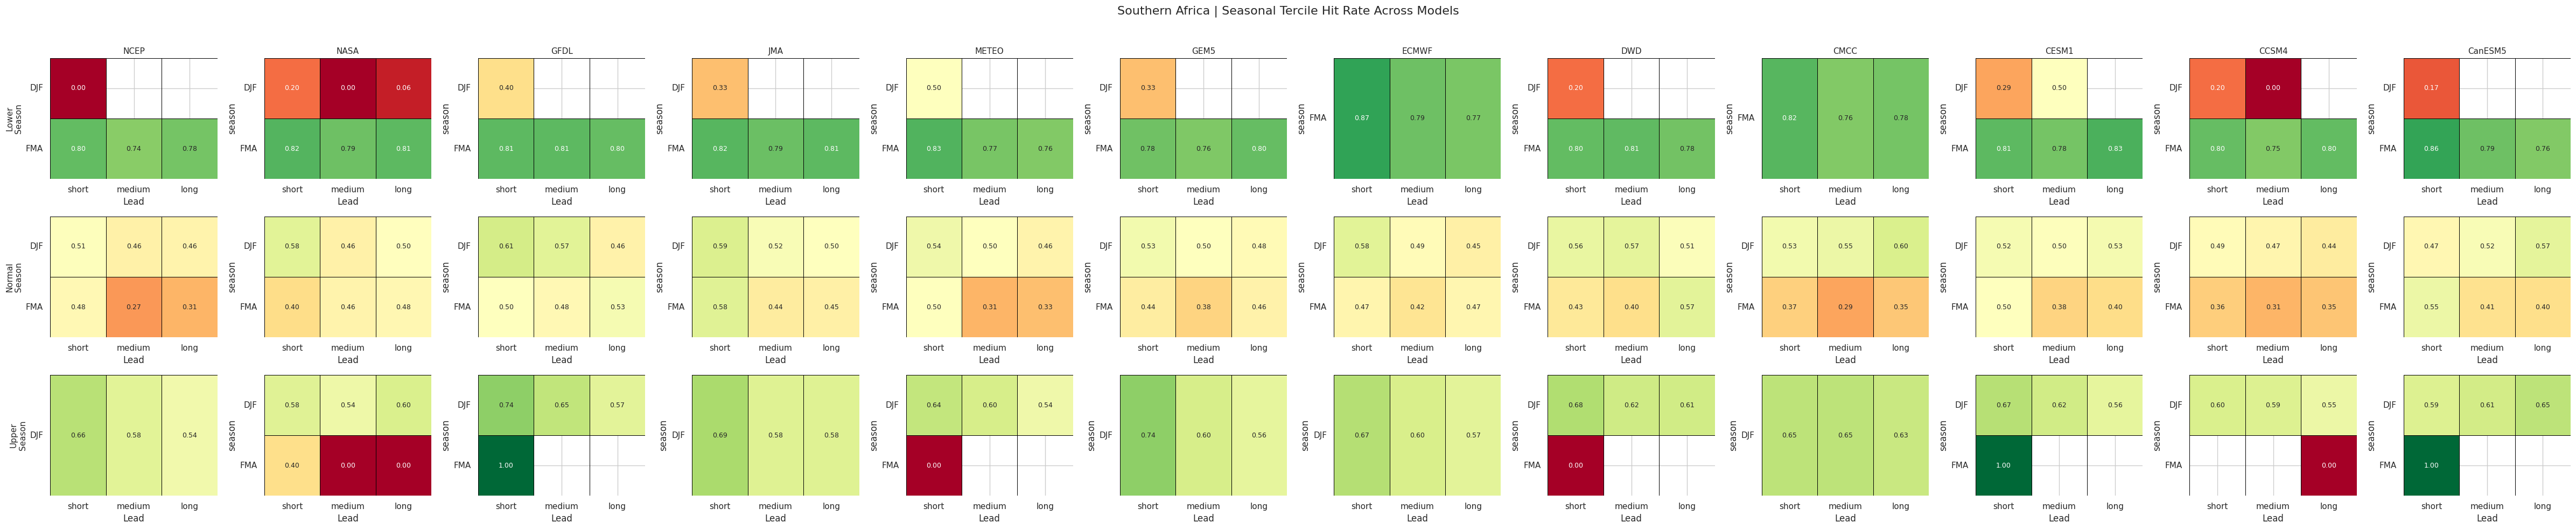

In [37]:
# Configuration
region = 'southern_africa'
models = ['NCEP', 'NASA', 'GFDL', 'JMA', 'METEO', 'GEM5', 'ECMWF', 'DWD', 'CMCC', 'CESM1', 'CCSM4', 'CanESM5']
season_months = {'DJF': [12, 1, 2], 'FMA': [2, 3, 4]}
terciles = ['lower', 'normal', 'upper']
all_months = sorted(set(m for months in season_months.values() for m in months))

def categorize_lead(lead):
    if 0 <= lead <= 1:
        return 'short'
    elif 2 <= lead <= 3:
        return 'medium'
    elif 4 <= lead <= 6:
        return 'long'
    return None

def assign_season(month):
    for sname, months in season_months.items():
        if month in months:
            return sname
    return None

# Prepare the subplot grid
fig, axes = plt.subplots(nrows=3, ncols=len(models), figsize=(4 * len(models), 10))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Loop over terciles and models
for row_idx, tercile_label in enumerate(terciles):
    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]
        file_path = f'/content/drive/MyDrive/capstone_data/csv/seasonal/{region}_{model}_merged_seasonal.csv'

        if not os.path.exists(file_path):
            ax.axis('off')
            ax.set_title(f"{model}\nFile Not Found", fontsize=10)
            continue

        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df['month'] = df['time'].dt.month
        df['lead_time'] = df['lead_time'].astype(int)
        df = df[df['month'].isin(all_months)]

        # Apply spatial mean
        df_grouped = df.groupby(['time', 'lead_time']).mean(numeric_only=True).reset_index()
        df_grouped['month'] = df_grouped['time'].dt.month
        df_grouped['lead_category'] = df_grouped['lead_time'].apply(categorize_lead)
        df_grouped['season'] = df_grouped['month'].apply(assign_season)
        df_grouped = df_grouped[df_grouped['lead_category'].notnull() & df_grouped['season'].notnull()]
        df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']

        # Tercile thresholds
        obs_lower = df_grouped['precip'].quantile(1/3)
        obs_upper = df_grouped['precip'].quantile(2/3)
        pred_lower = df_grouped['predicted_precip'].quantile(1/3)
        pred_upper = df_grouped['predicted_precip'].quantile(2/3)

        df_grouped['observed_tercile'] = df_grouped['precip'].apply(
            lambda val: 'lower' if val <= obs_lower else 'normal' if val <= obs_upper else 'upper')
        df_grouped['predicted_tercile'] = df_grouped['predicted_precip'].apply(
            lambda val: 'lower' if val <= pred_lower else 'normal' if val <= pred_upper else 'upper')

        df_grouped[f'{tercile_label}_hit'] = (
            (df_grouped['observed_tercile'] == tercile_label) &
            (df_grouped['predicted_tercile'] == tercile_label)
        ).astype(int)

        preds = df_grouped[df_grouped['predicted_tercile'] == tercile_label]
        hit_rate = preds.groupby('season_lead')[f'{tercile_label}_hit'].mean().reset_index()
        if hit_rate.empty:
            ax.axis('off')
            ax.set_title(f"{model}\nNo Data", fontsize=10)
            continue

        hit_rate[['season', 'lead']] = hit_rate['season_lead'].str.split('_', expand=True)
        pivot = hit_rate.pivot(index='season', columns='lead', values=f'{tercile_label}_hit')
        for col in ['short', 'medium', 'long']:
            if col not in pivot.columns:
                pivot[col] = float('nan')
        pivot = pivot[['short', 'medium', 'long']]

        # Plot
        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            linewidths=0.5,
            linecolor='black',
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9},
            cbar=False
        )

        if row_idx == 0:
            ax.set_title(model, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{tercile_label.capitalize()}\nSeason", fontsize=11)

        ax.set_xlabel("Lead")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle(f"{region.replace('_', ' ').title()} | Seasonal Tercile Hit Rate Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


SRI LANKA



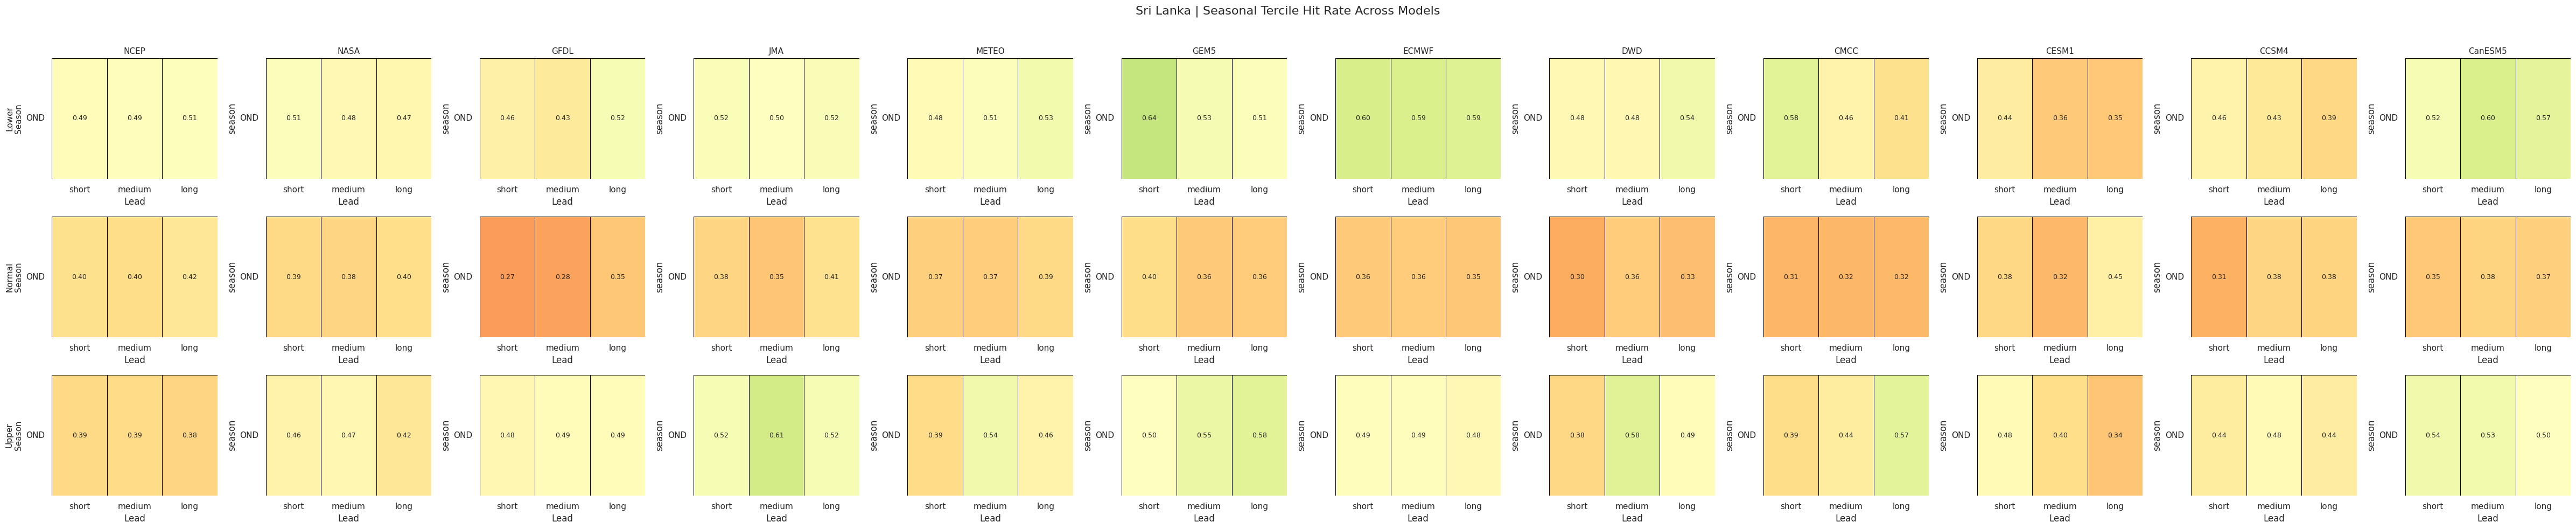

In [38]:
# Sri Lanka configuration
region = 'sri_lanka'
season_months = {'OND': [10, 11, 12]}
models = ['NCEP', 'NASA', 'GFDL', 'JMA', 'METEO', 'GEM5', 'ECMWF', 'DWD', 'CMCC', 'CESM1', 'CCSM4', 'CanESM5']
terciles = ['lower', 'normal', 'upper']
all_months = sorted(set(m for months in season_months.values() for m in months))

def categorize_lead(lead):
    if 0 <= lead <= 1:
        return 'short'
    elif 2 <= lead <= 3:
        return 'medium'
    elif 4 <= lead <= 6:
        return 'long'
    return None

def assign_season(month):
    for sname, months in season_months.items():
        if month in months:
            return sname
    return None

# Prepare subplot grid
fig, axes = plt.subplots(nrows=3, ncols=len(models), figsize=(4 * len(models), 10))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Iterate over terciles and models
for row_idx, tercile_label in enumerate(terciles):
    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]
        file_path = f'/content/drive/MyDrive/capstone_data/csv/seasonal/{region}_{model}_merged_seasonal.csv'

        if not os.path.exists(file_path):
            ax.axis('off')
            ax.set_title(f"{model}\nFile Not Found", fontsize=10)
            continue

        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df['month'] = df['time'].dt.month
        df['lead_time'] = df['lead_time'].astype(int)
        df = df[df['month'].isin(all_months)]

        # Spatial mean
        df_grouped = df.groupby(['time', 'lead_time']).mean(numeric_only=True).reset_index()
        df_grouped['month'] = df_grouped['time'].dt.month
        df_grouped['lead_category'] = df_grouped['lead_time'].apply(categorize_lead)
        df_grouped['season'] = df_grouped['month'].apply(assign_season)
        df_grouped = df_grouped[df_grouped['lead_category'].notnull() & df_grouped['season'].notnull()]
        df_grouped['season_lead'] = df_grouped['season'] + "_" + df_grouped['lead_category']

        obs_lower = df_grouped['precip'].quantile(1/3)
        obs_upper = df_grouped['precip'].quantile(2/3)
        pred_lower = df_grouped['predicted_precip'].quantile(1/3)
        pred_upper = df_grouped['predicted_precip'].quantile(2/3)

        df_grouped['observed_tercile'] = df_grouped['precip'].apply(
            lambda val: 'lower' if val <= obs_lower else 'normal' if val <= obs_upper else 'upper')
        df_grouped['predicted_tercile'] = df_grouped['predicted_precip'].apply(
            lambda val: 'lower' if val <= pred_lower else 'normal' if val <= pred_upper else 'upper')

        df_grouped[f'{tercile_label}_hit'] = (
            (df_grouped['observed_tercile'] == tercile_label) &
            (df_grouped['predicted_tercile'] == tercile_label)
        ).astype(int)

        preds = df_grouped[df_grouped['predicted_tercile'] == tercile_label]
        hit_rate = preds.groupby('season_lead')[f'{tercile_label}_hit'].mean().reset_index()

        if hit_rate.empty:
            ax.axis('off')
            ax.set_title(f"{model}\nNo Data", fontsize=10)
            continue

        hit_rate[['season', 'lead']] = hit_rate['season_lead'].str.split('_', expand=True)
        pivot = hit_rate.pivot(index='season', columns='lead', values=f'{tercile_label}_hit')

        for col in ['short', 'medium', 'long']:
            if col not in pivot.columns:
                pivot[col] = float('nan')
        pivot = pivot[['short', 'medium', 'long']]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            linewidths=0.5,
            linecolor='black',
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9},
            cbar=False
        )

        if row_idx == 0:
            ax.set_title(model, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{tercile_label.capitalize()}\nSeason", fontsize=11)

        ax.set_xlabel("Lead")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle(f"{region.replace('_', ' ').title()} | Seasonal Tercile Hit Rate Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
